# SMS Spam Detection Project

## Project Idea
This project aims to build a Machine Learning system that classifies SMS messages as either **Spam** or **Ham**.

The dataset contains SMS messages labeled as:
- `ham`: normal message
- `spam`: unwanted or promotional message

We will apply the full NLP pipeline:
1. Data Loading
2. Data Understanding
3. Data Visualization
4. Text Preprocessing
5. Feature Engineering
6. Model Training
7. Model Evaluation

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## 1. Load Dataset

The dataset is loaded from the `data/raw` folder.  
The original dataset contains extra unnamed columns, so we will keep only the useful columns:
- `v1`: label
- `v2`: SMS text

In [7]:

df = pd.read_csv("../data/raw/spam.csv",  encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Keep Needed Columns

In [8]:
df = df[['v1', 'v2']]
df.columns = ['label', 'text']

df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 2. Dataset Shape

We check the number of rows and columns in the dataset.

In [11]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5572
Number of columns: 2


## 3. Dataset Information

We check the data types and whether there are missing values.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


## 4. Missing Values Check

In [14]:
df.isnull().sum()

label    0
text     0
dtype: int64

## 5. Duplicate Samples Check

Duplicate messages may affect the model, so we check if there are repeated SMS messages.

In [15]:
print("Number of duplicated rows:", df.duplicated().sum())

Number of duplicated rows: 403


In [16]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (5169, 2)


## 6. Basic Statistics (Numerical Features)

Since the dataset is text-based, we create numerical features such as:
- Word count
- Character count

Then we compute basic statistics like mean, median, min, and max.

In [17]:
df["word_count"] = df["text"].apply(lambda x: len(x.split()))
df["char_count"] = df["text"].apply(lambda x: len(x))

In [18]:
df[["word_count", "char_count"]].describe()

,word_count,char_count
count,5169.000000,5169.000000
mean,15.340685,78.977945
std,11.068488,58.236293
min,1.000000,2.000000
25%,7.000000,36.000000
50%,12.000000,60.000000
75%,22.000000,117.000000
max,171.000000,910.000000


In [19]:
df.groupby("label")[["word_count", "char_count"]].mean()

,word_count,char_count
label,,
ham,14.134632,70.459256
spam,23.681470,137.891271


## 7. Target / Label Analysis

We analyze the distribution of the target variable (`label`) to check:
- Number of spam vs ham messages
- Whether the dataset is balanced or imbalanced

In [20]:
df['label'].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

In [21]:
df['label'].value_counts(normalize=True) * 100

label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64

## 8. Class Distribution Visualization

We visualize the class distribution using a bar chart.

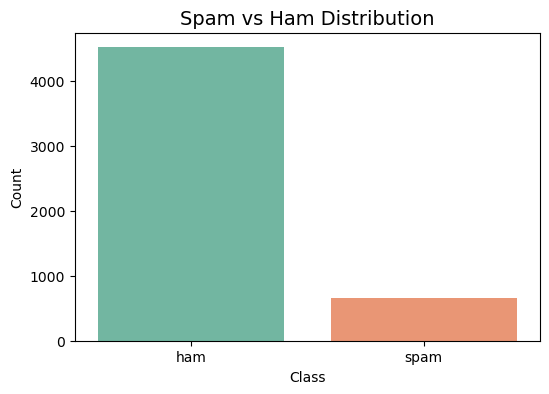

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette='Set2')

plt.title("Spam vs Ham Distribution", fontsize=14)
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

### Observation

- The dataset is clearly imbalanced.
- Ham messages are significantly more than spam messages.
- This imbalance can affect model performance, especially recall for the spam class.

### Solution (Later)

We will handle this using:
- Class weights  
or  
- SMOTE (oversampling)

## 9. Feature Analysis (Numerical Features)

We analyze the numerical features created from the text:
- Word count
- Character count

This helps us understand the distribution and detect outliers.

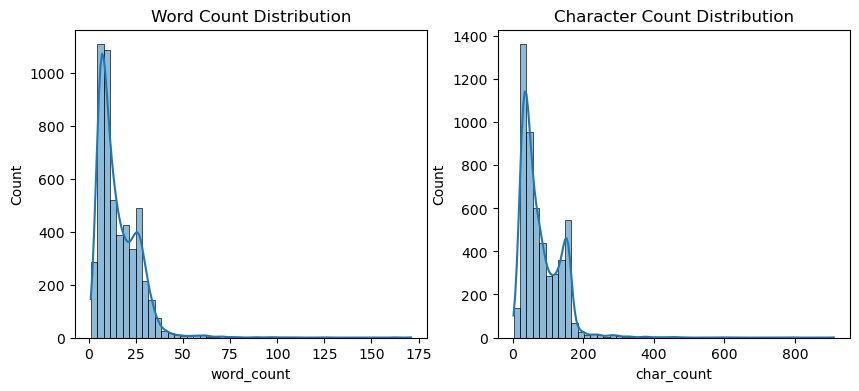

In [24]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title("Word Count Distribution")

plt.subplot(1,2,2)
sns.histplot(df['char_count'], bins=50, kde=True)
plt.title("Character Count Distribution")

plt.show()

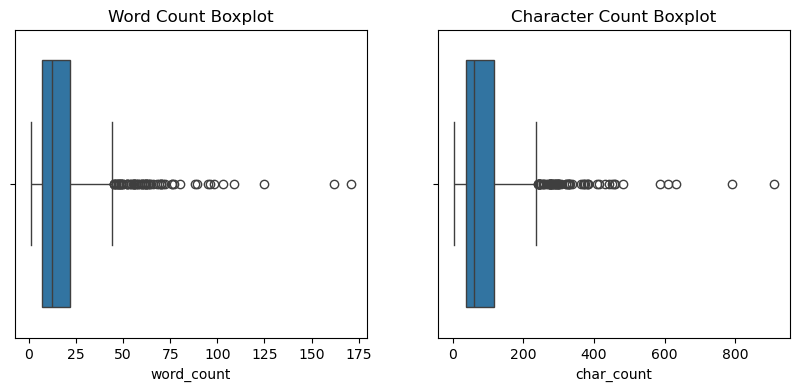

In [25]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=df['word_count'])
plt.title("Word Count Boxplot")

plt.subplot(1,2,2)
sns.boxplot(x=df['char_count'])
plt.title("Character Count Boxplot")

plt.show()

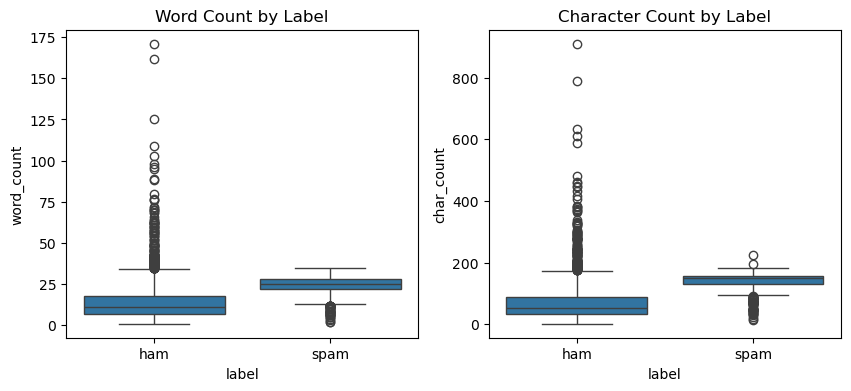

In [26]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x='label', y='word_count', data=df)
plt.title("Word Count by Label")

plt.subplot(1,2,2)
sns.boxplot(x='label', y='char_count', data=df)
plt.title("Character Count by Label")

plt.show()

### Outlier Observation

- There are some extreme values (very long messages).
- These are considered statistical outliers.
- However, they are valid data points and should not be removed.

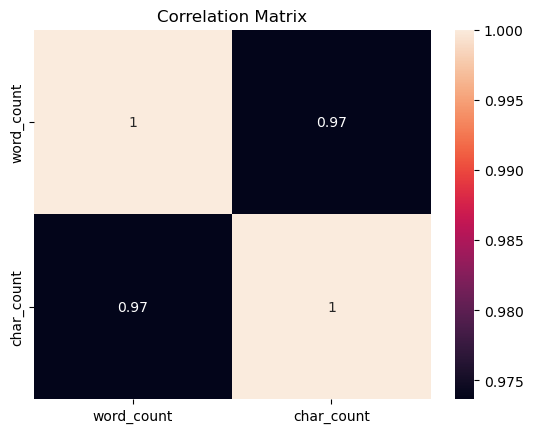

In [27]:
sns.heatmap(df[['word_count','char_count']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

## 10. Categorical Feature Analysis

We analyze the categorical feature (`label`) to understand:
- Frequency of each category
- Relationship between category and numerical features

In [28]:
df['label'].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

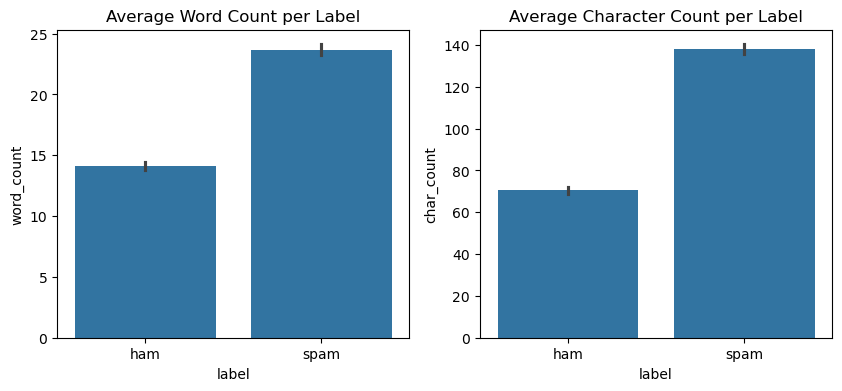

In [30]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.barplot(x='label', y='word_count', data=df)
plt.title("Average Word Count per Label")

plt.subplot(1,2,2)
sns.barplot(x='label', y='char_count', data=df)
plt.title("Average Character Count per Label")

plt.show()

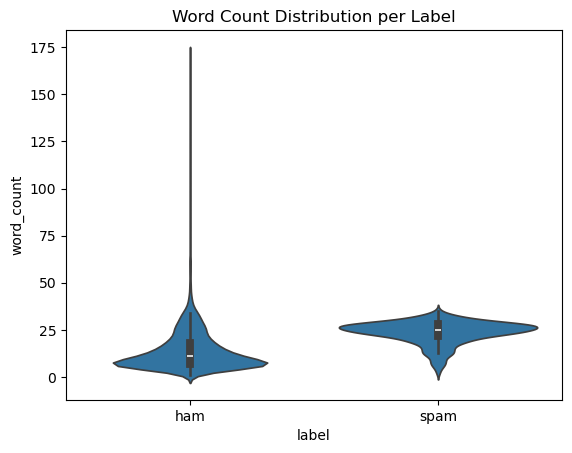

In [31]:
sns.violinplot(x='label', y='word_count', data=df)
plt.title("Word Count Distribution per Label")
plt.show()

## 11. Text Preprocessing

We clean the text data to prepare it for analysis and modeling.

Steps:
- Convert to lowercase
- Remove punctuation
- Remove numbers
- Remove stopwords
- Tokenization
- Applying lemmatization using WordNetLemmatizer

In [44]:
import re
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\menna\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\menna\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\menna\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\menna\AppData\Roaming\nltk_data...


In [46]:
nltk.download('punkt_tab') 

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\menna\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [47]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    
    text = text.lower()
    
    text = re.sub(r'[^a-z\s]', '', text)
    
    
    tokens = word_tokenize(text)
    
    
    tokens = [word for word in tokens if word not in stop_words]
    
    
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    
    return " ".join(tokens)

df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text']].head()

,text,clean_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


## 12. Most Common Words

In [34]:
from collections import Counter

all_words = " ".join(df['clean_text']).split()

word_counts = Counter(all_words)

word_counts.most_common(20)

[('u', 1020),
 ('call', 490),
 ('im', 459),
 ('get', 366),
 ('ur', 316),
 ('go', 272),
 ('dont', 269),
 ('ltgt', 254),
 ('ok', 251),
 ('free', 245),
 ('know', 239),
 ('got', 232),
 ('like', 231),
 ('good', 217),
 ('ill', 210),
 ('come', 210),
 ('time', 199),
 ('day', 191),
 ('want', 187),
 ('love', 178)]

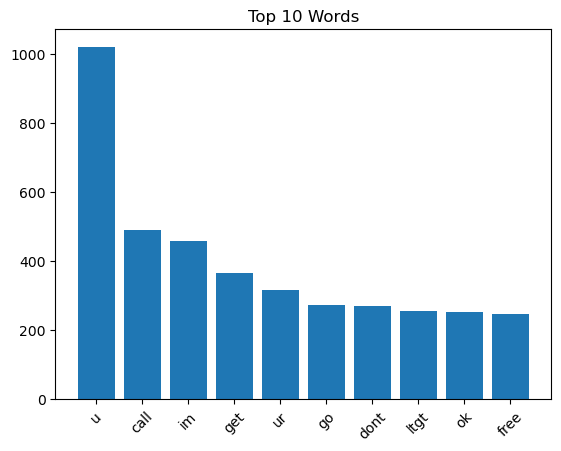

In [35]:
common_words = word_counts.most_common(10)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.bar(words, counts)
plt.title("Top 10 Words")
plt.xticks(rotation=45)
plt.show()

In [36]:
spam_words = " ".join(df[df['label']=='spam']['clean_text']).split()
ham_words = " ".join(df[df['label']=='ham']['clean_text']).split()

spam_common = Counter(spam_words).most_common(10)
ham_common = Counter(ham_words).most_common(10)

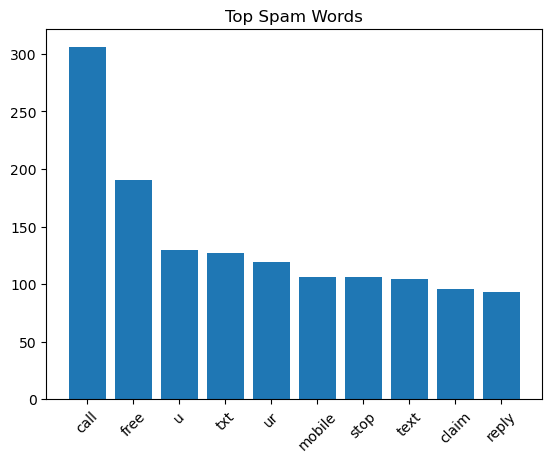

In [37]:
words = [w[0] for w in spam_common]
counts = [w[1] for w in spam_common]

plt.bar(words, counts)
plt.title("Top Spam Words")
plt.xticks(rotation=45)
plt.show()

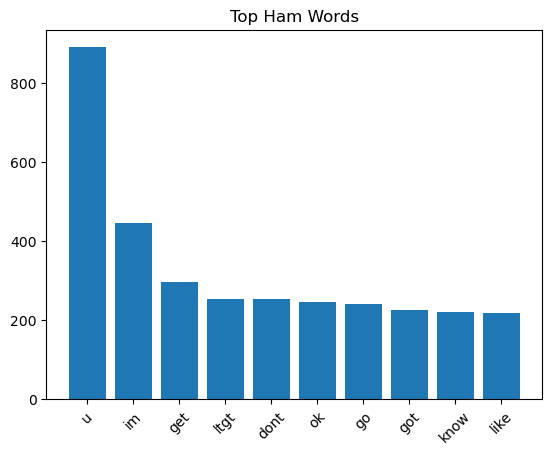

In [38]:
words = [w[0] for w in ham_common]
counts = [w[1] for w in ham_common]

plt.bar(words, counts)
plt.title("Top Ham Words")
plt.xticks(rotation=45)
plt.show()

### Insight

- Spam messages contain promotional words such as:
  free,call, prize

- Ham messages contain normal conversational words.

In [40]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


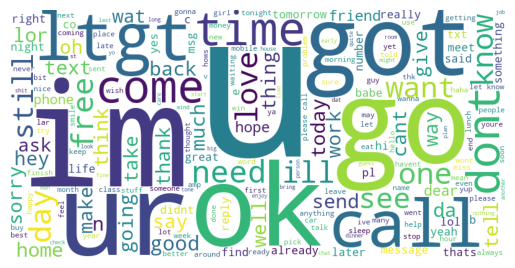

In [41]:
from wordcloud import WordCloud

wc = WordCloud(width=800, height=400, background_color='white').generate(" ".join(df['clean_text']))

plt.imshow(wc)
plt.axis('off')
plt.show()

## 15. WordCloud for Spam Messages

We generate a separate WordCloud for spam messages to identify common spam-related words.

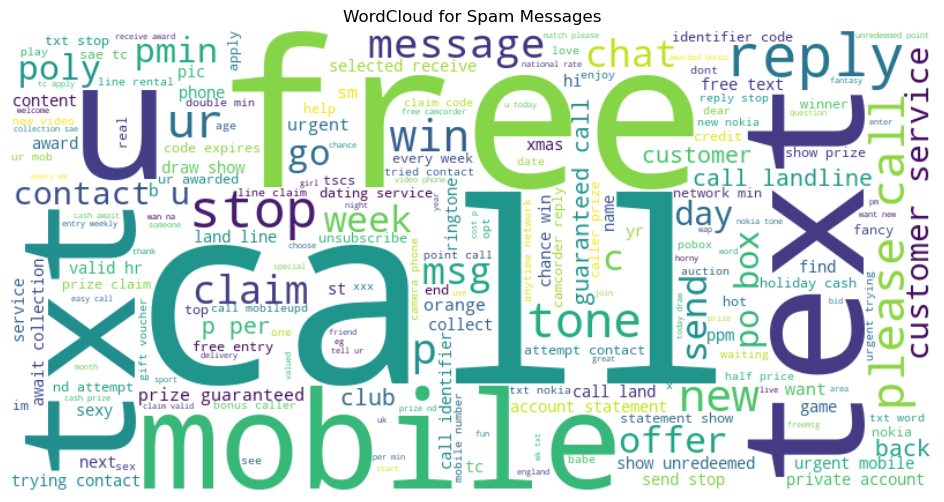

In [48]:
spam_clean_text = " ".join(df[df["label"] == "spam"]["clean_text"])

spam_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(spam_clean_text)

plt.figure(figsize=(12,6))
plt.imshow(spam_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud for Spam Messages")
plt.show()

## 16. WordCloud for Ham Messages

We generate a separate WordCloud for ham messages to understand normal conversation patterns.

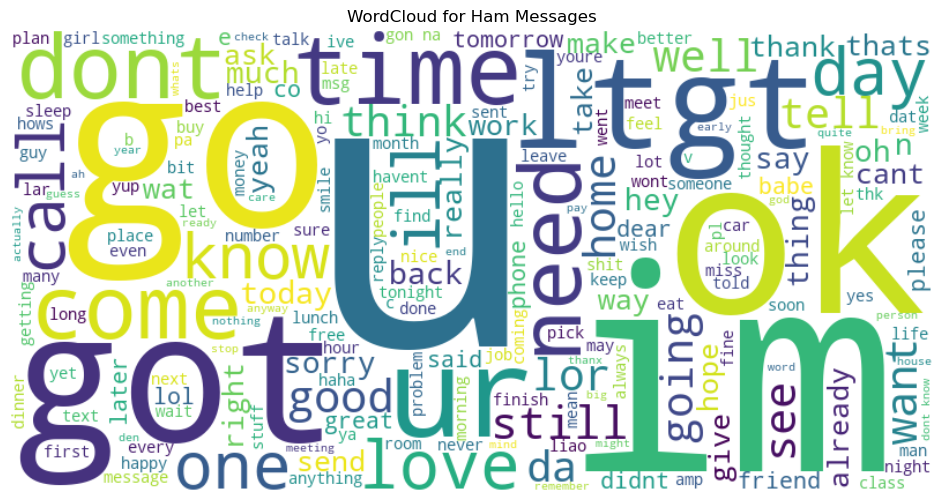

In [49]:
ham_clean_text = " ".join(df[df["label"] == "ham"]["clean_text"])

ham_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(ham_clean_text)

plt.figure(figsize=(12,6))
plt.imshow(ham_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud for Ham Messages")
plt.show()

In [50]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(text_data, ngram_range=(2,2), top_n=15):
    vectorizer = CountVectorizer(ngram_range=ngram_range)
    
    ngram_matrix = vectorizer.fit_transform(text_data)
    
    ngram_counts = ngram_matrix.sum(axis=0)
    
    ngrams = [
        (ngram, ngram_counts[0, idx])
        for ngram, idx in vectorizer.vocabulary_.items()
    ]
    
    ngrams = sorted(ngrams, key=lambda x: x[1], reverse=True)
    
    return ngrams[:top_n]

In [51]:
top_bigrams = get_top_ngrams(df["clean_text"], ngram_range=(2,2), top_n=15)

top_bigrams

[('gon na', 58),
 ('please call', 46),
 ('let know', 42),
 ('wan na', 38),
 ('dont know', 33),
 ('new year', 30),
 ('im going', 26),
 ('take care', 26),
 ('po box', 24),
 ('customer service', 23),
 ('call landline', 23),
 ('good morning', 23),
 ('guaranteed call', 21),
 ('im gon', 20),
 ('prize guaranteed', 20)]

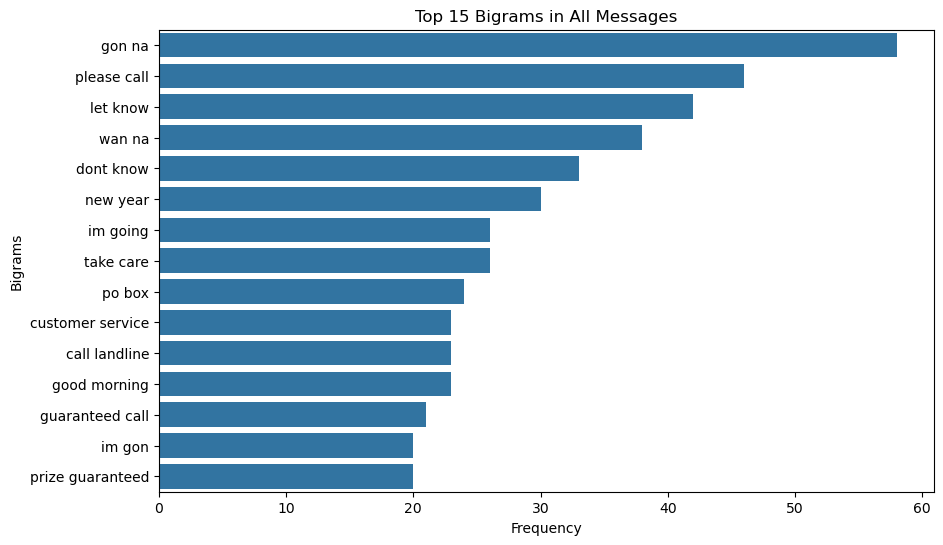

In [52]:
bigrams = [item[0] for item in top_bigrams]
counts = [item[1] for item in top_bigrams]

plt.figure(figsize=(10,6))
sns.barplot(x=counts, y=bigrams)

plt.title("Top 15 Bigrams in All Messages")
plt.xlabel("Frequency")
plt.ylabel("Bigrams")

plt.show()

## 19. Top Bigrams in Spam Messages

We analyze bigrams in spam messages to discover repeated spam patterns.

In [54]:
spam_bigrams = get_top_ngrams(
    df[df["label"] == "spam"]["clean_text"],
    ngram_range=(2,2),
    top_n=15
)

spam_bigrams

[('please call', 41),
 ('po box', 23),
 ('customer service', 22),
 ('call landline', 22),
 ('guaranteed call', 21),
 ('prize guaranteed', 20),
 ('urgent mobile', 17),
 ('send stop', 17),
 ('claim call', 16),
 ('call claim', 16),
 ('valid hr', 16),
 ('selected receive', 16),
 ('call land', 16),
 ('land line', 16),
 ('await collection', 16)]

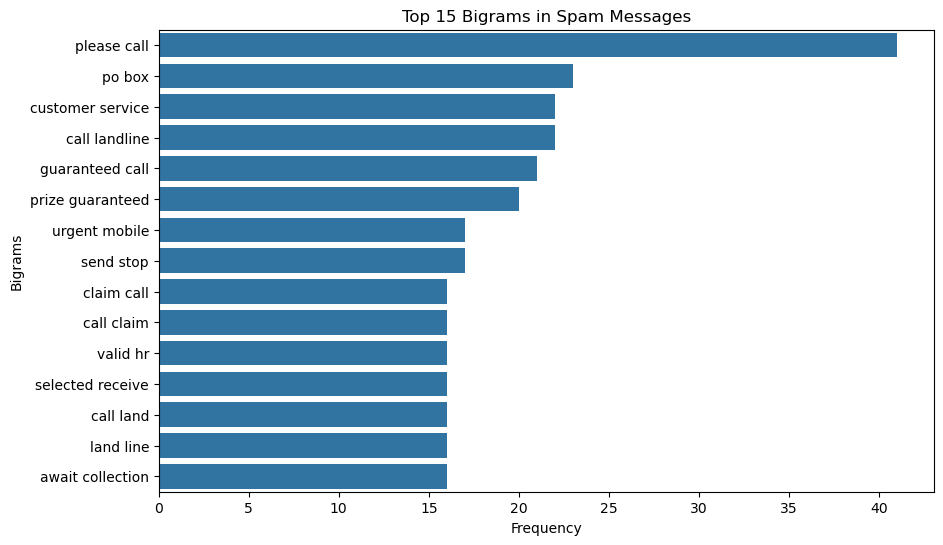

In [55]:
bigrams = [item[0] for item in spam_bigrams]
counts = [item[1] for item in spam_bigrams]

plt.figure(figsize=(10,6))
sns.barplot(x=counts, y=bigrams)

plt.title("Top 15 Bigrams in Spam Messages")
plt.xlabel("Frequency")
plt.ylabel("Bigrams")

plt.show()

## 20. Top Bigrams in Ham Messages

We analyze bigrams in ham messages to understand normal conversation patterns.

In [56]:
ham_bigrams = get_top_ngrams(
    df[df["label"] == "ham"]["clean_text"],
    ngram_range=(2,2),
    top_n=15
)

ham_bigrams

[('gon na', 58),
 ('let know', 42),
 ('dont know', 31),
 ('wan na', 28),
 ('new year', 28),
 ('im going', 26),
 ('take care', 26),
 ('good morning', 23),
 ('im gon', 20),
 ('ltgt min', 19),
 ('ok lor', 19),
 ('hi hi', 18),
 ('wat time', 18),
 ('last night', 18),
 ('ill call', 17)]

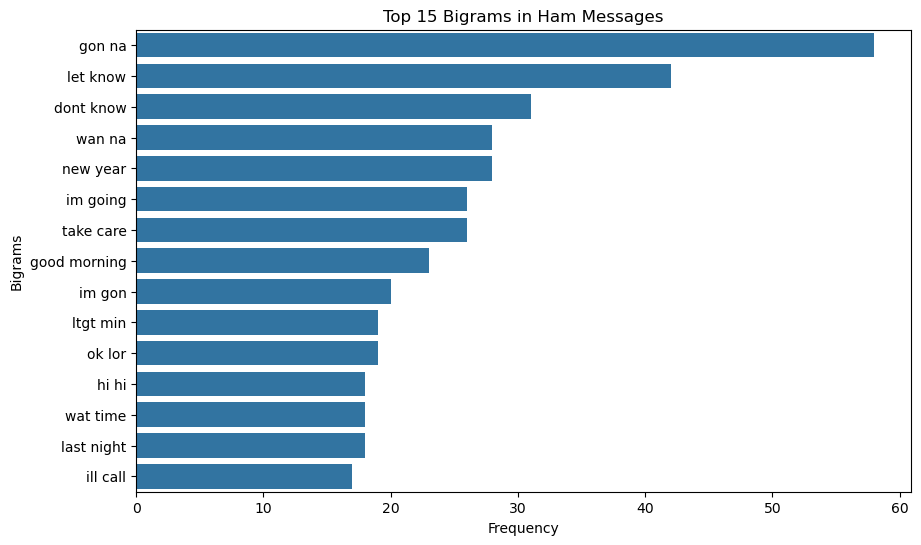

In [57]:
bigrams = [item[0] for item in ham_bigrams]
counts = [item[1] for item in ham_bigrams]

plt.figure(figsize=(10,6))
sns.barplot(x=counts, y=bigrams)

plt.title("Top 15 Bigrams in Ham Messages")
plt.xlabel("Frequency")
plt.ylabel("Bigrams")

plt.show()

## 21. Skewness Detection

We analyze the distribution of numerical features to check if they are skewed.

Skewness indicates whether the data is balanced or has extreme values.

In [58]:
df[['word_count', 'char_count']].skew()

word_count    2.743122
char_count    2.610100
dtype: float64

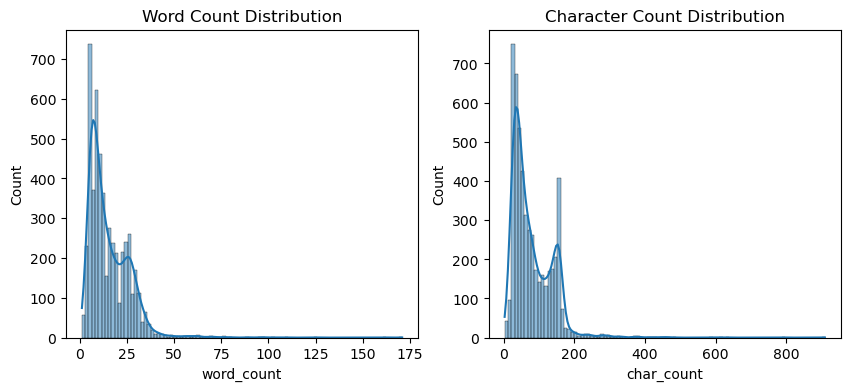

In [59]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['word_count'], kde=True)
plt.title("Word Count Distribution")

plt.subplot(1,2,2)
sns.histplot(df['char_count'], kde=True)
plt.title("Character Count Distribution")

plt.show()

In [60]:
df.sample(5)

,label,text,word_count,char_count,clean_text
5127,ham,Cuz ibored. And don wanna study,6,31,cuz ibored wan na study
5364,spam,Call 09095350301 and send our girls into eroti...,18,112,call send girl erotic ecstacy pmin stop text c...
3556,ham,I had it already..sabarish asked me to go..,8,43,alreadysabarish asked go
2583,ham,"Goodmorning, today i am late for 1hr.",7,37,goodmorning today late hr
1972,ham,Yes but can we meet in town cos will go to gep...,31,143,yes meet town co go gep home could text bus st...


## 24. Feature Scaling Check

We check whether numerical features require scaling before modeling.

## Additional Feature: Punctuation Count

We calculate the number of punctuation marks in each message.
Spam messages often contain more punctuation to grab attention.

In [62]:
import string

def count_punctuation(text):
    return sum(1 for char in text if char in string.punctuation)

df['punctuation_count'] = df['text'].apply(count_punctuation)

df[['text', 'punctuation_count']].head()

,text,punctuation_count
0,"Go until jurong point, crazy.. Available only ...",9
1,Ok lar... Joking wif u oni...,6
2,Free entry in 2 a wkly comp to win FA Cup fina...,6
3,U dun say so early hor... U c already then say...,6
4,"Nah I don't think he goes to usf, he lives aro...",2


In [63]:
df.groupby('label')['punctuation_count'].mean()

label
ham     3.865810
spam    5.649311
Name: punctuation_count, dtype: float64

## 25. Feature Engineering (TF-IDF)

TF-IDF is used to convert text data into numerical features.

- TF measures how frequently a word appears in a document
- IDF reduces the importance of common words across documents

This helps highlight important words for classification.

## Train-Test Split

The dataset is split into training and testing sets.

We use stratified splitting because the dataset is imbalanced, and we want to preserve the same spam/ham ratio in both training and testing data.

In [72]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["label"].map({"ham": 0, "spam": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [65]:
X.shape

(5169, 3000)

In [74]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

## 26. Logistic Regression (Baseline Model)

We start with Logistic Regression as a baseline model for text classification.

In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression()

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9632495164410058
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       903
           1       0.99      0.72      0.83       131

    accuracy                           0.96      1034
   macro avg       0.98      0.86      0.91      1034
weighted avg       0.96      0.96      0.96      1034



## 27. Cross Validation

Cross-validation is used to evaluate the model on multiple splits of the data.

This helps ensure that the model is stable and not overfitting.

In [76]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross-validation scores: [0.94679565 0.95042322 0.95163241 0.95767836 0.95767836]
Mean CV Accuracy: 0.9528415961305925


## 28. Hyperparameter Tuning (GridSearchCV)

We tune the model parameters to improve performance.

In [77]:
from sklearn.model_selection import GridSearchCV

params = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear']
}

grid = GridSearchCV(
    LogisticRegression(),
    param_grid=params,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train_tfidf, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'C': 10, 'solver': 'liblinear'}
Best Score: 0.9746070133010882


In [78]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       903
           1       0.96      0.85      0.90       131

    accuracy                           0.98      1034
   macro avg       0.97      0.92      0.95      1034
weighted avg       0.98      0.98      0.98      1034



## 29. Model Comparison

We train multiple machine learning models and compare their performance using:
- Accuracy
-  Precision
- Recall
- F1-score
- ROC-AUC
- Cross-validation score

In [80]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.model_selection import cross_val_score

In [82]:
models = {
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}
results = []

for name, model in models.items():
    
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    
    # بعض المودلات تحتاج probability
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_tfidf)[:, 1]
    else:
        y_prob = model.decision_function(X_test_tfidf)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.963250,0.989474,0.717557,0.831858,0.993140
1,SVM,0.974855,0.981651,0.816794,0.891667,0.994290
2,KNN,0.914894,1.000000,0.328244,0.494253,0.785583
3,Decision Tree,0.945841,0.831858,0.717557,0.770492,0.845705
4,Random Forest,0.972921,0.972477,0.809160,0.883333,0.989310


In [85]:
acc_results = []

for name, model in models.items():
    
    model.fit(X_train_tfidf, y_train)
    
    train_pred = model.predict(X_train_tfidf)
    test_pred = model.predict(X_test_tfidf)
    
    acc_results.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred)
    })

acc_df = pd.DataFrame(acc_results)
acc_df

,Model,Train Accuracy,Test Accuracy
0,Logistic Regression,0.970012,0.963250
1,SVM,0.995163,0.974855
2,KNN,0.928658,0.914894
3,Decision Tree,0.999758,0.942940
4,Random Forest,0.999758,0.976789


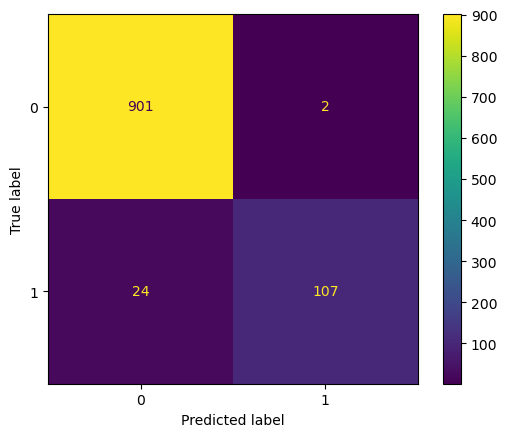

In [84]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model = models["SVM"] 

y_pred = best_model.predict(X_test_tfidf)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()


### Model Comparison Insight

- SVM achieved the best overall performance with high accuracy, precision, recall, and ROC-AUC.
- Random Forest also performed very well with balanced metrics.
- KNN showed very poor recall, making it unsuitable for spam detection.

## Hyperparameter Tuning

After comparing the baseline models, we selected the best-performing models for hyperparameter tuning.

We tune:
- SVM
- Random Forest

The goal is to improve the model performance by finding the best parameter values.

In [86]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

svm_params = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

svm_grid = GridSearchCV(
    estimator=SVC(probability=True),
    param_grid=svm_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

svm_grid.fit(X_train_tfidf, y_train)

print("Best SVM Parameters:", svm_grid.best_params_)
print("Best SVM CV F1-score:", svm_grid.best_score_)

Best SVM Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best SVM CV F1-score: 0.9051214404206206


In [87]:
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train_tfidf, y_train)

print("Best Random Forest Parameters:", rf_grid.best_params_)
print("Best Random Forest CV F1-score:", rf_grid.best_score_)

Best Random Forest Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best Random Forest CV F1-score: 0.8717942576804194


In [88]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

tuned_models = {
    "Tuned SVM": svm_grid.best_estimator_,
    "Tuned Random Forest": rf_grid.best_estimator_
}

tuned_results = []

for name, model in tuned_models.items():
    y_pred = model.predict(X_test_tfidf)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_tfidf)[:, 1]
    else:
        y_prob = model.decision_function(X_test_tfidf)

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Tuned SVM,0.980658,0.982609,0.862595,0.918699,0.995646
1,Tuned Random Forest,0.976789,0.981982,0.832061,0.900826,0.990925


## Ensemble Method: AdaBoost

AdaBoost is a boosting algorithm that combines multiple weak learners to create a strong classifier.

It focuses on misclassified samples and tries to improve them in each iteration.

In [89]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada_model.fit(X_train_tfidf, y_train)

y_pred = ada_model.predict(X_test_tfidf)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_prob = ada_model.predict_proba(X_test_tfidf)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.9700193423597679
Precision: 0.9385964912280702
Recall: 0.816793893129771
F1: 0.8734693877551021
ROC-AUC: 0.949967453695485


### Ensemble Models Insight

- Random Forest and AdaBoost improved performance compared to simple models.
- However, SVM still achieved the best overall balance.
- AdaBoost performed well but slightly lower than Random Forest and SVM.

## Handling Class Imbalance using Class Weight

Since the dataset is imbalanced, we try class weighting to give more importance to the minority class (spam).

This helps the model focus more on spam messages and may improve recall.

In [91]:

balanced_models = {
    "Balanced SVM": SVC(class_weight="balanced", probability=True, random_state=42),
    "Balanced Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42)
}

balanced_results = []

for name, model in balanced_models.items():
    
    model.fit(X_train_tfidf, y_train)
    
    y_pred = model.predict(X_test_tfidf)
    y_prob = model.predict_proba(X_test_tfidf)[:, 1]
    
    balanced_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

balanced_results_df = pd.DataFrame(balanced_results)
balanced_results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Balanced SVM,0.976789,0.973451,0.839695,0.901639,0.993148
1,Balanced Random Forest,0.973888,0.981481,0.809160,0.887029,0.991487


In [92]:
comparison_df = pd.concat([results_df, balanced_results_df], ignore_index=True)
comparison_df.sort_values(by="F1-score", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
5,Balanced SVM,0.976789,0.973451,0.839695,0.901639,0.993148
1,SVM,0.974855,0.981651,0.816794,0.891667,0.994290
6,Balanced Random Forest,0.973888,0.981481,0.809160,0.887029,0.991487
4,Random Forest,0.972921,0.972477,0.809160,0.883333,0.989310
0,Logistic Regression,0.963250,0.989474,0.717557,0.831858,0.993140
3,Decision Tree,0.945841,0.831858,0.717557,0.770492,0.845705
2,KNN,0.914894,1.000000,0.328244,0.494253,0.785583


### Final Model Selection

- Balanced SVM achieved the best overall performance across all evaluation metrics.
- It improved recall and F1-score compared to the original SVM.
- This makes it the most suitable model for spam detection.

### Imbalance Handling Insight

- Applying class_weight improved model performance, especially recall.
- This is important because detecting spam messages is more critical than avoiding false alarms.

## Confusion Matrix

The confusion matrix shows the performance of the final model in terms of:
- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

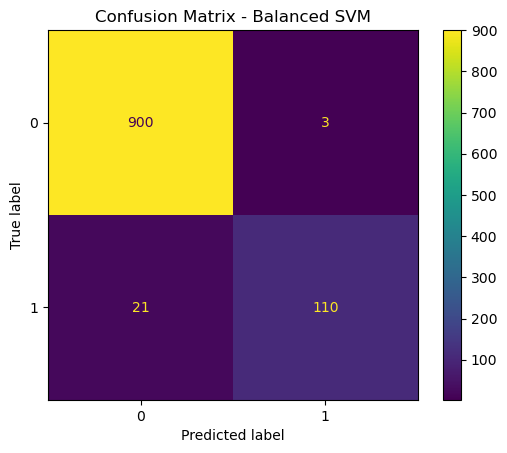

In [94]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

final_model = SVC(class_weight="balanced", probability=True, random_state=42)
final_model.fit(X_train_tfidf, y_train)

y_pred = final_model.predict(X_test_tfidf)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Balanced SVM")
plt.show()

## ROC Curve

The ROC curve shows the trade-off between True Positive Rate (Recall) and False Positive Rate.

A higher AUC indicates better model performance.

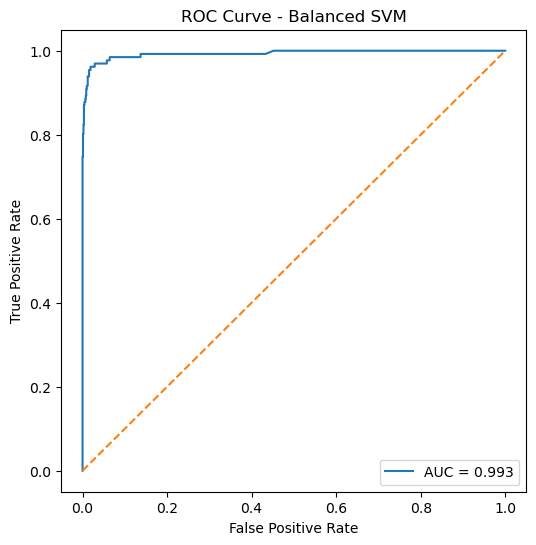

In [95]:
from sklearn.metrics import roc_curve, auc

y_prob = final_model.predict_proba(X_test_tfidf)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Balanced SVM")
plt.legend()

plt.show()

In [96]:
y_prob = final_model.predict_proba(X_test_tfidf)[:, 1]

threshold = 0.4

y_pred_custom = (y_prob >= threshold).astype(int)

In [97]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       903
           1       0.94      0.89      0.91       131

    accuracy                           0.98      1034
   macro avg       0.96      0.94      0.95      1034
weighted avg       0.98      0.98      0.98      1034



In [98]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import pandas as pd

y_prob = final_model.predict_proba(X_test_tfidf)[:, 1]

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)
    
    cm = confusion_matrix(y_test, y_pred_threshold)
    
    tn, fp, fn, tp = cm.ravel()
    
    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1-score": f1_score(y_test, y_pred_threshold),
        "False Positives": fp,
        "False Negatives": fn
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Threshold,Accuracy,Precision,Recall,F1-score,False Positives,False Negatives
0,0.2,0.980658,0.899281,0.954198,0.925926,14,6
1,0.3,0.980658,0.937008,0.908397,0.922481,8,12
2,0.4,0.978723,0.943089,0.885496,0.913386,7,15
3,0.5,0.980658,0.966387,0.877863,0.920000,4,16
4,0.6,0.980658,0.966387,0.877863,0.920000,4,16


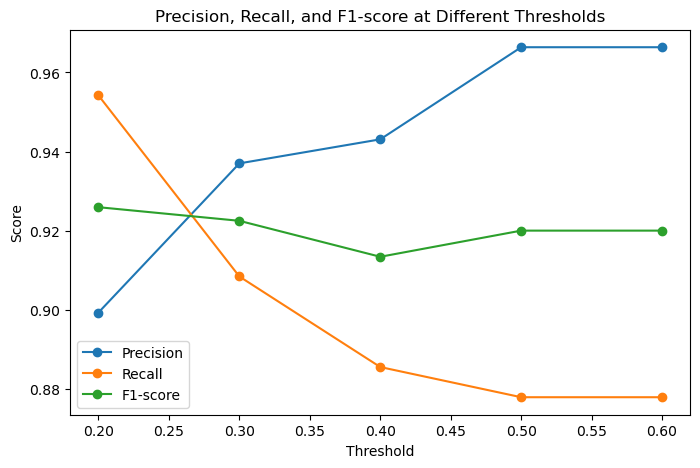

In [99]:
plt.figure(figsize=(8,5))

plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1-score"], marker="o", label="F1-score")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1-score at Different Thresholds")
plt.legend()
plt.show()

In [100]:
best_threshold_row = threshold_df.sort_values(by="F1-score", ascending=False).iloc[0]

best_threshold_row

Threshold           0.200000
Accuracy            0.980658
Precision           0.899281
Recall              0.954198
F1-score            0.925926
False Positives    14.000000
False Negatives     6.000000
Name: 0, dtype: float64

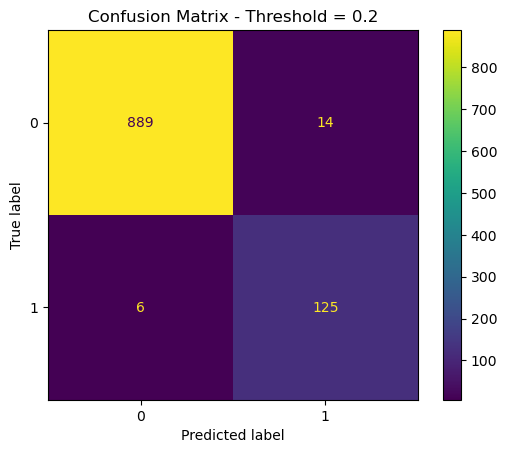

In [101]:
best_threshold = best_threshold_row["Threshold"]

y_pred_best_threshold = (y_prob >= best_threshold).astype(int)

cm_best = confusion_matrix(y_test, y_pred_best_threshold)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_best)
disp.plot()

plt.title(f"Confusion Matrix - Threshold = {best_threshold}")
plt.show()

### Threshold Optimization

We adjusted the classification threshold to improve recall and reduce false negatives.

- Lowering the threshold increased the model's sensitivity to spam messages.
- This reduced false negatives significantly (from 21 to 6).

### Final Decision

We selected threshold = 0.2 because it achieved:
- Highest F1-score
- Very high recall (important for spam detection)
- Acceptable precision

### Final Model

Balanced SVM with optimized threshold (0.2) achieved the best performance.

## Bonus: Advanced Text Representation using BERT Embeddings

In addition to TF-IDF, we use pretrained BERT embeddings to represent SMS messages as dense semantic vectors.

Each SMS message is converted into a numerical vector that captures its meaning, not only word frequency.

In [102]:
from sentence_transformers import SentenceTransformer

bert_model = SentenceTransformer("all-MiniLM-L6-v2")

X_train_bert = bert_model.encode(X_train.tolist(), show_progress_bar=True)
X_test_bert = bert_model.encode(X_test.tolist(), show_progress_bar=True)

print(X_train_bert.shape)
print(X_test_bert.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/130 [00:00<?, ?it/s]

Batches:   0%|          | 0/33 [00:00<?, ?it/s]

(4135, 384)
(1034, 384)


In [103]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

bert_svm = SVC(class_weight="balanced", probability=True, random_state=42)

bert_svm.fit(X_train_bert, y_train)

y_pred_bert = bert_svm.predict(X_test_bert)
y_prob_bert = bert_svm.predict_proba(X_test_bert)[:, 1]

bert_results = {
    "Model": "BERT Embeddings + Balanced SVM",
    "Accuracy": accuracy_score(y_test, y_pred_bert),
    "Precision": precision_score(y_test, y_pred_bert),
    "Recall": recall_score(y_test, y_pred_bert),
    "F1-score": f1_score(y_test, y_pred_bert),
    "ROC-AUC": roc_auc_score(y_test, y_prob_bert)
}

bert_results

{'Model': 'BERT Embeddings + Balanced SVM',
 'Accuracy': 0.9825918762088974,
 'Precision': 0.9669421487603306,
 'Recall': 0.8931297709923665,
 'F1-score': 0.9285714285714286,
 'ROC-AUC': 0.9943530048269974}

In [104]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")
joblib.dump(final_model, "../models/balanced_svm_tfidf.pkl")

print("TF-IDF vectorizer and TF-IDF SVM model saved successfully.")

TF-IDF vectorizer and TF-IDF SVM model saved successfully.


In [105]:
joblib.dump(bert_svm, "../models/bert_balanced_svm.pkl")

print("BERT SVM classifier saved successfully.")

BERT SVM classifier saved successfully.


In [106]:
with open("../models/bert_model_name.txt", "w") as f:
    f.write("all-MiniLM-L6-v2")

print("BERT model name saved successfully.")

BERT model name saved successfully.


In [107]:
loaded_tfidf = joblib.load("../models/tfidf_vectorizer.pkl")
loaded_tfidf_model = joblib.load("../models/balanced_svm_tfidf.pkl")

sample = ["Free entry in a weekly competition, claim your prize now!"]

sample_tfidf = loaded_tfidf.transform(sample)
prediction = loaded_tfidf_model.predict(sample_tfidf)

print(prediction)

[1]
